## Cell 1 — Imports, versions, and constants

In [1]:

from __future__ import annotations

import gc
import json
import shutil
import subprocess
import sys
import time
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.patches import Rectangle

try:
    import shap
except ImportError:
    # Install SHAP only when it is missing from the Kaggle environment.
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "shap",
        ]
    )
    import shap

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPU was not detected. Enable a Kaggle GPU accelerator."
    )

RANDOM_SEED = 42
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
NUMBER_OF_CLASSES = 43
PREDICTION_BATCH_SIZE = 32

HIGH_CONFIDENCE_SAMPLES = 2
LOW_CONFIDENCE_SAMPLES = 2
DIFFICULT_SAMPLES = 2

# SHAP recommends roughly 300–500 model evaluations for image explanations.
MAX_EVALS = 300
SHAP_BATCH_SIZE = 32

# The blur masker is model-agnostic and avoids architecture-specific code.
MASKER_SPECIFICATION = "blur(32,32)"

# Keep only the ZIP file in /kaggle/working after archiving.
REMOVE_UNPACKED_OUTPUT_AFTER_ZIP = True

tf.keras.utils.set_random_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


TensorFlow: 2.20.0
SHAP: 0.51.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Locate GTSRB and trained models

In [2]:

INPUT_ROOT = Path("/kaggle/input")


def find_gtsrb_root() -> Path:
    # Locate GTSRB using its CSV files and image folders.
    for train_csv in INPUT_ROOT.rglob("Train.csv"):
        candidate = train_csv.parent

        if (
            (candidate / "Test.csv").exists()
            and (candidate / "Train").is_dir()
            and (candidate / "Test").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "The GTSRB dataset root was not found under /kaggle/input."
    )


def find_model_file(filename: str) -> Path:
    # Search recursively because Kaggle may add extra folder levels.
    matches = sorted(
        INPUT_ROOT.rglob(filename),
        key=lambda path: (len(path.parts), str(path)),
    )

    if not matches:
        raise FileNotFoundError(
            f"The model file was not found: {filename}"
        )

    if len(matches) > 1:
        print(f"Warning: multiple matches found for {filename}")
        for match in matches:
            print(" ", match)
        print("Using:", matches[0])

    return matches[0]


DATASET_ROOT = find_gtsrb_root()

MODEL_PATHS = {
    "Custom CNN": find_model_file("best_custom_cnn.keras"),
    "EfficientNetV2B0": find_model_file("best_efficientnetv2b0.keras"),
    "ConvNeXtTiny": find_model_file("best_convnexttiny.keras"),
}

MODEL_INPUT_RANGES = {
    "Custom CNN": "zero_one",
    "EfficientNetV2B0": "zero_255",
    "ConvNeXtTiny": "zero_255",
}

print("GTSRB root:", DATASET_ROOT)
print("\nModel files:")
for model_name, model_path in MODEL_PATHS.items():
    print(f"{model_name}: {model_path}")


GTSRB root: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Model files:
Custom CNN: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_custom_cnn.keras
EfficientNetV2B0: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_efficientnetv2b0.keras
ConvNeXtTiny: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_convnexttiny.keras


## Cell 3 — Output folders and class names

In [3]:

OUTPUT_ROOT = Path("/kaggle/working/shap_outputs")
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"
COMPARISON_DIR = FIGURE_DIR / "comparisons"
INDIVIDUAL_DIR = FIGURE_DIR / "individual"
ATTRIBUTION_ARRAY_DIR = OUTPUT_ROOT / "attribution_arrays"

for directory in [
    OUTPUT_ROOT,
    REPORT_DIR,
    FIGURE_DIR,
    COMPARISON_DIR,
    INDIVIDUAL_DIR,
    ATTRIBUTION_ARRAY_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 t",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 t prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice or snow",
    31: "Wild animals crossing",
    32: "End of speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing for vehicles over 3.5 t",
}

CLASS_NAME_LIST = [
    CLASS_NAMES[class_id]
    for class_id in range(NUMBER_OF_CLASSES)
]

if len(CLASS_NAME_LIST) != NUMBER_OF_CLASSES:
    raise ValueError(
        "The class-name mapping must contain exactly 43 classes."
    )

print("Output root:", OUTPUT_ROOT)
print("Class names:", len(CLASS_NAME_LIST))


Output root: /kaggle/working/shap_outputs
Class names: 43


## Cell 4 — Load Test.csv and define image preprocessing

In [4]:

test_frame = pd.read_csv(
    DATASET_ROOT / "Test.csv"
)

required_columns = ["Path", "ClassId"]
missing_columns = [
    column
    for column in required_columns
    if column not in test_frame.columns
]

if missing_columns:
    raise KeyError(
        f"Missing Test.csv columns: {missing_columns}"
    )


def resolve_image_path(relative_path: str) -> str:
    # Normalize path separators and create an absolute Kaggle path.
    normalized = (
        str(relative_path)
        .replace("\\", "/")
        .lstrip("/")
    )
    return str(DATASET_ROOT / normalized)


test_frame["absolute_path"] = (
    test_frame["Path"]
    .map(resolve_image_path)
)

missing_images = [
    path
    for path in test_frame["absolute_path"]
    if not Path(path).exists()
]

if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} test images were not found. "
        f"First missing image: {missing_images[0]}"
    )

if len(test_frame) != 12630:
    raise ValueError(
        f"Expected 12630 test images, found {len(test_frame)}."
    )

if test_frame["ClassId"].nunique() != NUMBER_OF_CLASSES:
    raise ValueError(
        "The test manifest does not contain all 43 classes."
    )

TEST_PATHS = test_frame["absolute_path"].astype(str).to_numpy()
TRUE_LABELS = test_frame["ClassId"].astype(np.int64).to_numpy()

ROI_COLUMNS = [
    "Width",
    "Height",
    "Roi.X1",
    "Roi.Y1",
    "Roi.X2",
    "Roi.Y2",
]

ROI_AVAILABLE = all(
    column in test_frame.columns
    for column in ROI_COLUMNS
)


def load_image_255(path: tf.Tensor) -> tf.Tensor:
    # Load an RGB image and resize it to 224 x 224 in the [0, 255] range.
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH],
        method="bilinear",
        antialias=True,
    )

    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)

    return tf.ensure_shape(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH, 3],
    )


def prepare_model_input_numpy(
    images_255: np.ndarray,
    input_range: str,
) -> np.ndarray:
    # Match the input range used during model training.
    images = np.asarray(
        images_255,
        dtype=np.float32,
    )

    if images.ndim == 2:
        images = images.reshape(
            -1,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            3,
        )

    if input_range == "zero_one":
        return images / 255.0

    if input_range == "zero_255":
        return images

    raise ValueError(
        f"Unsupported model input range: {input_range}"
    )


def build_prediction_dataset(
    input_range: str,
) -> tf.data.Dataset:
    # Build a deterministic dataset in the Test.csv order.
    dataset = tf.data.Dataset.from_tensor_slices(TEST_PATHS)

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)

    def map_example(
        image_path: tf.Tensor,
    ) -> tf.Tensor:
        image_255 = load_image_255(image_path)

        if input_range == "zero_one":
            return image_255 / 255.0

        if input_range == "zero_255":
            return image_255

        raise ValueError(
            f"Unsupported input range: {input_range}"
        )

    dataset = dataset.map(
        map_example,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )

    dataset = dataset.batch(
        PREDICTION_BATCH_SIZE,
        drop_remainder=False,
    )

    return dataset.prefetch(tf.data.AUTOTUNE)


print("Test images:", len(test_frame))
print("Classes:", test_frame["ClassId"].nunique())
print("ROI columns available:", ROI_AVAILABLE)


Test images: 12630
Classes: 43
ROI columns available: True


## Cell 5 — Validate models and predict the clean test set

In [5]:

prediction_store: dict[str, np.ndarray] = {}
analysis_frame = test_frame.copy()
model_information = []


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)
    print("Processing:", model_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    if tuple(model.input_shape[1:]) != (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        3,
    ):
        raise ValueError(
            f"{model_name} has an unexpected input shape: "
            f"{model.input_shape}"
        )

    if int(model.output_shape[-1]) != NUMBER_OF_CLASSES:
        raise ValueError(
            f"{model_name} has an unexpected output shape: "
            f"{model.output_shape}"
        )

    model_information.append(
        {
            "model": model_name,
            "input_shape": str(model.input_shape),
            "output_shape": str(model.output_shape),
            "parameter_count": int(model.count_params()),
            "model_file_size_mb": float(
                model_path.stat().st_size
                / 1024
                / 1024
            ),
        }
    )

    dataset = build_prediction_dataset(
        MODEL_INPUT_RANGES[model_name]
    )

    probabilities = model.predict(
        dataset,
        verbose=0,
    )

    expected_shape = (
        len(test_frame),
        NUMBER_OF_CLASSES,
    )

    if probabilities.shape != expected_shape:
        raise ValueError(
            f"{model_name} returned {probabilities.shape}; "
            f"expected {expected_shape}."
        )

    probabilities = probabilities.astype(np.float32)
    prediction_store[model_name] = probabilities

    predicted_classes = np.argmax(
        probabilities,
        axis=1,
    )

    confidences = np.max(
        probabilities,
        axis=1,
    )

    model_key = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    analysis_frame[
        f"{model_key}_predicted_class"
    ] = predicted_classes

    analysis_frame[
        f"{model_key}_confidence"
    ] = confidences

    analysis_frame[
        f"{model_key}_correct"
    ] = (
        predicted_classes
        == TRUE_LABELS
    )

    print(
        "Clean accuracy:",
        float(
            np.mean(
                predicted_classes
                == TRUE_LABELS
            )
        ),
    )

    del model
    del dataset
    gc.collect()


tf.keras.backend.clear_session()
gc.collect()

pd.DataFrame(
    model_information
).to_csv(
    REPORT_DIR / "model_information.csv",
    index=False,
)

analysis_frame.to_csv(
    REPORT_DIR / "clean_test_predictions_all_models.csv",
    index=False,
)

print("Clean predictions completed.")



Processing: Custom CNN


I0000 00:00:1784777298.108756      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1784777303.884288      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Clean accuracy: 0.8536817102137767

Processing: EfficientNetV2B0
Clean accuracy: 0.847347585114806

Processing: ConvNeXtTiny
Clean accuracy: 0.934916864608076
Clean predictions completed.


## Cell 6 — Select representative samples

In [6]:

model_keys = [
    model_name
    .lower()
    .replace(" ", "_")
    for model_name in MODEL_PATHS
]

correct_columns = [
    f"{model_key}_correct"
    for model_key in model_keys
]

confidence_columns = [
    f"{model_key}_confidence"
    for model_key in model_keys
]

analysis_frame[
    "all_models_correct"
] = analysis_frame[
    correct_columns
].all(axis=1)

analysis_frame[
    "wrong_model_count"
] = (
    len(correct_columns)
    - analysis_frame[
        correct_columns
    ].sum(axis=1)
)

analysis_frame[
    "mean_confidence"
] = analysis_frame[
    confidence_columns
].mean(axis=1)

analysis_frame[
    "minimum_confidence"
] = analysis_frame[
    confidence_columns
].min(axis=1)


def select_unique_rows(
    candidates: pd.DataFrame,
    count: int,
    category: str,
    used_indices: set[int],
) -> pd.DataFrame:
    # Select rows that were not used by an earlier category.
    available = candidates[
        ~candidates.index.isin(
            used_indices
        )
    ].head(count).copy()

    available[
        "selection_category"
    ] = category

    used_indices.update(
        int(index)
        for index in available.index
    )

    return available


used_indices: set[int] = set()
selected_parts = []

high_confidence_candidates = (
    analysis_frame[
        analysis_frame[
            "all_models_correct"
        ]
    ]
    .sort_values(
        [
            "mean_confidence",
            "minimum_confidence",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        high_confidence_candidates,
        HIGH_CONFIDENCE_SAMPLES,
        "high_confidence_correct",
        used_indices,
    )
)

low_confidence_candidates = (
    analysis_frame[
        analysis_frame[
            "all_models_correct"
        ]
    ]
    .sort_values(
        [
            "mean_confidence",
            "minimum_confidence",
        ],
        ascending=[
            True,
            True,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        low_confidence_candidates,
        LOW_CONFIDENCE_SAMPLES,
        "low_confidence_correct",
        used_indices,
    )
)

difficult_candidates = (
    analysis_frame[
        analysis_frame[
            "wrong_model_count"
        ] > 0
    ]
    .sort_values(
        [
            "wrong_model_count",
            "mean_confidence",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        difficult_candidates,
        DIFFICULT_SAMPLES,
        "difficult_or_misclassified",
        used_indices,
    )
)

selected_frame = pd.concat(
    selected_parts,
    axis=0,
)

expected_selected_count = (
    HIGH_CONFIDENCE_SAMPLES
    + LOW_CONFIDENCE_SAMPLES
    + DIFFICULT_SAMPLES
)

if len(selected_frame) < expected_selected_count:
    remaining_count = (
        expected_selected_count
        - len(selected_frame)
    )

    fallback_candidates = (
        analysis_frame[
            ~analysis_frame.index.isin(
                used_indices
            )
        ]
        .sort_values(
            "mean_confidence",
            ascending=True,
        )
    )

    fallback = select_unique_rows(
        fallback_candidates,
        remaining_count,
        "fallback_difficult",
        used_indices,
    )

    selected_frame = pd.concat(
        [
            selected_frame,
            fallback,
        ],
        axis=0,
    )

selected_frame = (
    selected_frame
    .reset_index()
    .rename(
        columns={
            "index": "test_row_index"
        }
    )
)

selected_frame.insert(
    0,
    "sample_id",
    [
        f"sample_{index:02d}"
        for index in range(
            1,
            len(selected_frame) + 1
        )
    ],
)

selected_frame[
    "true_class_name"
] = selected_frame[
    "ClassId"
].map(CLASS_NAMES)

selected_frame.to_csv(
    REPORT_DIR / "selected_shap_samples.csv",
    index=False,
)

display(
    selected_frame[
        [
            "sample_id",
            "selection_category",
            "ClassId",
            "true_class_name",
            "wrong_model_count",
            "mean_confidence",
            "Path",
        ]
    ]
)


,sample_id,selection_category,ClassId,true_class_name,wrong_model_count,mean_confidence,Path
0,sample_01,high_confidence_correct,13,Yield,0,1.000000,Test/00026.png
1,sample_02,high_confidence_correct,17,No entry,0,1.000000,Test/00031.png
2,sample_03,low_confidence_correct,2,Speed limit 50 km/h,0,0.505970,Test/07491.png
3,sample_04,low_confidence_correct,3,Speed limit 60 km/h,0,0.538991,Test/07837.png
4,sample_05,difficult_or_misclassified,37,Go straight or left,3,0.994686,Test/03789.png
5,sample_06,difficult_or_misclassified,5,Speed limit 80 km/h,3,0.985951,Test/04422.png


## Cell 7 — Visualize selected images

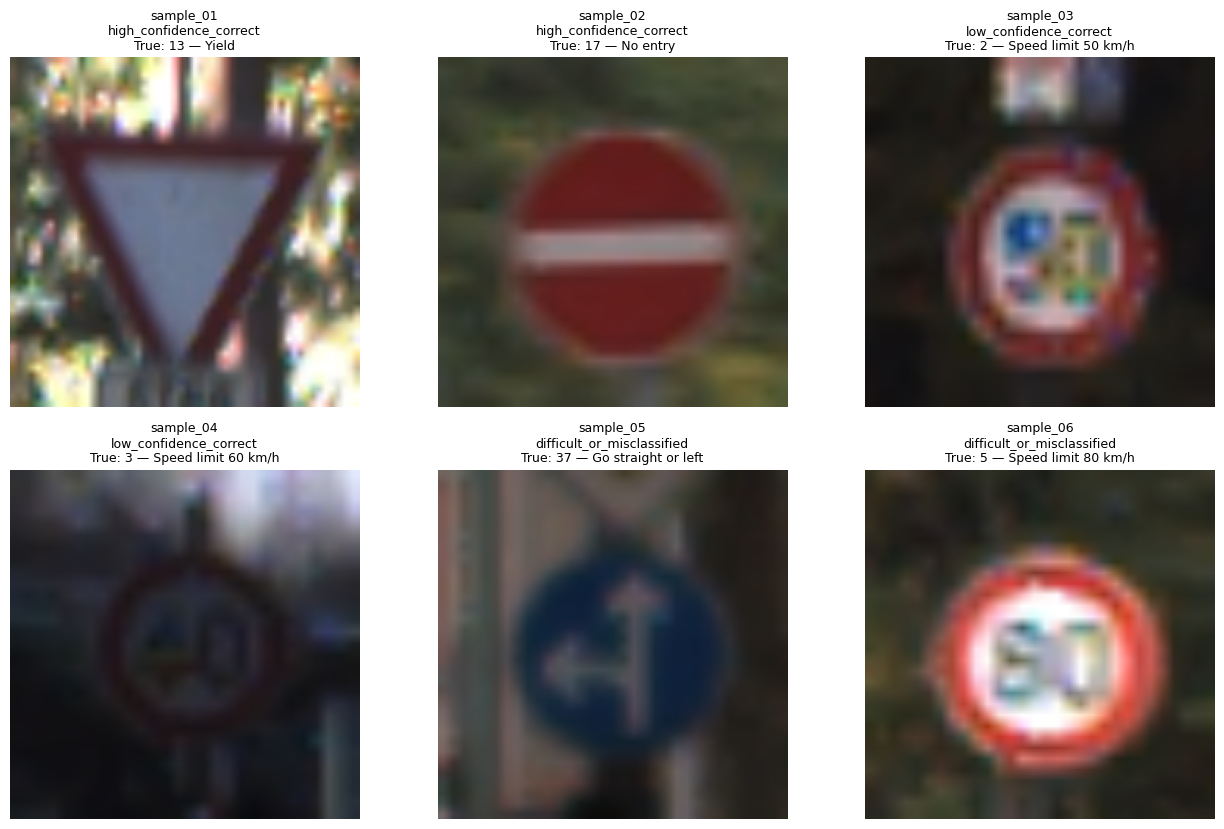

In [7]:

column_count = 3
row_count = int(
    np.ceil(
        len(selected_frame)
        / column_count
    )
)

figure, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(
        13,
        4.2 * row_count,
    ),
)

axes = np.asarray(axes).reshape(-1)

for axis_index, axis in enumerate(axes):
    if axis_index >= len(selected_frame):
        axis.axis("off")
        continue

    row = selected_frame.iloc[axis_index]

    image = load_image_255(
        tf.constant(
            row["absolute_path"]
        )
    ).numpy().astype(np.uint8)

    axis.imshow(image)

    axis.set_title(
        f"{row['sample_id']}\n"
        f"{row['selection_category']}\n"
        f"True: {int(row['ClassId'])} — "
        f"{CLASS_NAMES[int(row['ClassId'])]}",
        fontsize=9,
    )

    axis.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "selected_original_samples.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "selected_original_samples.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## Cell 8 — SHAP helper functions

In [8]:

def create_prediction_function(
    model: tf.keras.Model,
    input_range: str,
) -> Callable[[np.ndarray], np.ndarray]:
    # Wrap a Keras model for the model-agnostic SHAP image explainer.
    def predict_function(
        images_255: np.ndarray,
    ) -> np.ndarray:
        model_inputs = prepare_model_input_numpy(
            images_255,
            input_range,
        )

        predictions = model.predict(
            model_inputs,
            batch_size=PREDICTION_BATCH_SIZE,
            verbose=0,
        )

        return np.asarray(
            predictions,
            dtype=np.float32,
        )

    return predict_function


def extract_single_output_values(
    explanation: shap.Explanation,
) -> np.ndarray:
    # Extract one image and one explained output from a SHAP Explanation.
    values = np.asarray(
        explanation.values
    )

    if values.shape[0] != 1:
        raise ValueError(
            f"Expected one explained image, found shape {values.shape}."
        )

    values = values[0]

    if (
        values.ndim == 4
        and values.shape[-1] == 1
    ):
        values = values[..., 0]

    if values.ndim != 3:
        raise ValueError(
            f"Unexpected SHAP shape after slicing: {values.shape}"
        )

    if values.shape != (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        3,
    ):
        raise ValueError(
            f"Unexpected SHAP image shape: {values.shape}"
        )

    return values.astype(np.float32)


def create_signed_map(
    channel_values: np.ndarray,
) -> np.ndarray:
    # Sum RGB contributions into one signed spatial attribution map.
    return channel_values.sum(
        axis=-1
    ).astype(np.float32)


def normalize_signed_map(
    signed_map: np.ndarray,
) -> np.ndarray:
    # Normalize the signed map to the [-1, 1] range.
    maximum_absolute_value = float(
        np.max(
            np.abs(
                signed_map
            )
        )
    )

    if maximum_absolute_value <= 0:
        return np.zeros_like(
            signed_map,
            dtype=np.float32,
        )

    return (
        signed_map
        / maximum_absolute_value
    ).astype(np.float32)


def create_signed_overlay(
    image_255: np.ndarray,
    normalized_signed_map: np.ndarray,
    maximum_alpha: float = 0.72,
) -> np.ndarray:
    # Blend negative contributions in blue and positive contributions in red.
    color_map = plt.get_cmap(
        "coolwarm"
    )

    color_values = color_map(
        (
            normalized_signed_map
            + 1.0
        )
        / 2.0
    )[..., :3]

    color_values = (
        color_values
        * 255.0
    )

    alpha = (
        np.abs(
            normalized_signed_map
        )[..., np.newaxis]
        * maximum_alpha
    )

    overlay = (
        image_255.astype(np.float32)
        * (1.0 - alpha)
        + color_values.astype(np.float32)
        * alpha
    )

    return np.clip(
        overlay,
        0.0,
        255.0,
    ).astype(np.uint8)


def resized_roi(
    row: pd.Series,
) -> tuple[int, int, int, int] | None:
    # Convert original GTSRB ROI coordinates to 224 x 224 coordinates.
    if not ROI_AVAILABLE:
        return None

    original_width = float(
        row["Width"]
    )
    original_height = float(
        row["Height"]
    )

    if (
        original_width <= 0
        or original_height <= 0
    ):
        return None

    x_scale = (
        IMAGE_WIDTH
        / original_width
    )
    y_scale = (
        IMAGE_HEIGHT
        / original_height
    )

    x1 = int(
        round(
            float(row["Roi.X1"])
            * x_scale
        )
    )
    y1 = int(
        round(
            float(row["Roi.Y1"])
            * y_scale
        )
    )
    x2 = int(
        round(
            float(row["Roi.X2"])
            * x_scale
        )
    )
    y2 = int(
        round(
            float(row["Roi.Y2"])
            * y_scale
        )
    )

    x1 = int(
        np.clip(
            x1,
            0,
            IMAGE_WIDTH - 1,
        )
    )
    y1 = int(
        np.clip(
            y1,
            0,
            IMAGE_HEIGHT - 1,
        )
    )
    x2 = int(
        np.clip(
            x2,
            x1 + 1,
            IMAGE_WIDTH,
        )
    )
    y2 = int(
        np.clip(
            y2,
            y1 + 1,
            IMAGE_HEIGHT,
        )
    )

    return (
        x1,
        y1,
        x2,
        y2,
    )


def roi_absolute_attribution_ratio(
    signed_map: np.ndarray,
    roi: tuple[int, int, int, int] | None,
) -> float | None:
    # Measure the fraction of absolute SHAP attribution inside the sign ROI.
    if roi is None:
        return None

    absolute_map = np.abs(
        signed_map
    )

    total_attribution = float(
        absolute_map.sum()
    )

    if total_attribution <= 0:
        return 0.0

    x1, y1, x2, y2 = roi

    roi_attribution = float(
        absolute_map[
            y1:y2,
            x1:x2,
        ].sum()
    )

    return (
        roi_attribution
        / total_attribution
    )


def safe_model_name(
    model_name: str,
) -> str:
    # Convert a model name into a safe lowercase directory name.
    return (
        model_name
        .lower()
        .replace(" ", "_")
    )


## Cell 9 — SHAP smoke test

In [9]:

smoke_model_name = "Custom CNN"
smoke_model_path = MODEL_PATHS[
    smoke_model_name
]

tf.keras.backend.clear_session()
gc.collect()

smoke_model = tf.keras.models.load_model(
    smoke_model_path,
    compile=False,
)

smoke_prediction_function = create_prediction_function(
    smoke_model,
    MODEL_INPUT_RANGES[
        smoke_model_name
    ],
)

smoke_image = load_image_255(
    tf.constant(
        selected_frame.iloc[0][
            "absolute_path"
        ]
    )
).numpy()[
    np.newaxis,
    ...
]

smoke_masker = shap.maskers.Image(
    MASKER_SPECIFICATION,
    smoke_image[0].shape,
)

smoke_explainer = shap.Explainer(
    smoke_prediction_function,
    smoke_masker,
    output_names=CLASS_NAME_LIST,
    algorithm="partition",
    seed=RANDOM_SEED,
)

smoke_start = time.perf_counter()

smoke_values = smoke_explainer(
    smoke_image,
    max_evals=100,
    batch_size=SHAP_BATCH_SIZE,
    outputs=shap.Explanation.argsort.flip[:1],
    silent=True,
)

smoke_seconds = (
    time.perf_counter()
    - smoke_start
)

smoke_attributions = extract_single_output_values(
    smoke_values
)

print(
    "Smoke SHAP value shape:",
    smoke_attributions.shape,
)
print(
    "Smoke-test time, seconds:",
    round(
        smoke_seconds,
        2,
    ),
)

del smoke_values
del smoke_explainer
del smoke_masker
del smoke_model
tf.keras.backend.clear_session()
gc.collect()

print(
    "SHAP smoke test completed successfully."
)


Smoke SHAP value shape: (224, 224, 3)
Smoke-test time, seconds: 8.88
SHAP smoke test completed successfully.


## Cell 10 — Full SHAP comparison

In [10]:

shap_records: list[
    dict[str, Any]
] = []

comparison_data: dict[
    str,
    dict[str, Any]
] = {}


for _, selected_row in selected_frame.iterrows():
    sample_id = str(
        selected_row[
            "sample_id"
        ]
    )

    image_255 = load_image_255(
        tf.constant(
            selected_row[
                "absolute_path"
            ]
        )
    ).numpy().astype(np.uint8)

    comparison_data[
        sample_id
    ] = {
        "row": selected_row,
        "image": image_255,
        "roi": resized_roi(
            selected_row
        ),
        "overlays": {},
        "predictions": {},
    }


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)
    print("Creating SHAP explainer for:", model_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    prediction_function = create_prediction_function(
        model,
        MODEL_INPUT_RANGES[
            model_name
        ],
    )

    masker = shap.maskers.Image(
        MASKER_SPECIFICATION,
        (
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            3,
        ),
    )

    explainer = shap.Explainer(
        prediction_function,
        masker,
        output_names=CLASS_NAME_LIST,
        algorithm="partition",
        seed=RANDOM_SEED,
    )

    model_key = safe_model_name(
        model_name
    )

    model_figure_dir = (
        INDIVIDUAL_DIR
        / model_key
    )
    model_array_dir = (
        ATTRIBUTION_ARRAY_DIR
        / model_key
    )

    model_figure_dir.mkdir(
        parents=True,
        exist_ok=True,
    )
    model_array_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    for _, selected_row in selected_frame.iterrows():
        sample_id = str(
            selected_row[
                "sample_id"
            ]
        )
        test_row_index = int(
            selected_row[
                "test_row_index"
            ]
        )
        true_class = int(
            selected_row[
                "ClassId"
            ]
        )

        probabilities = prediction_store[
            model_name
        ][
            test_row_index
        ]

        predicted_class = int(
            np.argmax(
                probabilities
            )
        )
        confidence = float(
            probabilities[
                predicted_class
            ]
        )

        image_255 = load_image_255(
            tf.constant(
                selected_row[
                    "absolute_path"
                ]
            )
        ).numpy().astype(np.float32)

        shap_start = time.perf_counter()

        explanation = explainer(
            image_255[
                np.newaxis,
                ...
            ],
            max_evals=MAX_EVALS,
            batch_size=SHAP_BATCH_SIZE,
            outputs=shap.Explanation.argsort.flip[:1],
            silent=True,
        )

        shap_seconds = (
            time.perf_counter()
            - shap_start
        )

        channel_attributions = (
            extract_single_output_values(
                explanation
            )
        )

        signed_map = create_signed_map(
            channel_attributions
        )
        normalized_signed_map = (
            normalize_signed_map(
                signed_map
            )
        )
        overlay = create_signed_overlay(
            image_255.astype(np.uint8),
            normalized_signed_map,
        )

        roi = resized_roi(
            selected_row
        )
        roi_ratio = (
            roi_absolute_attribution_ratio(
                signed_map,
                roi,
            )
        )

        positive_sum = float(
            np.clip(
                signed_map,
                0.0,
                None,
            ).sum()
        )
        negative_sum = float(
            np.clip(
                -signed_map,
                0.0,
                None,
            ).sum()
        )
        absolute_sum = float(
            np.abs(
                signed_map
            ).sum()
        )

        array_path = (
            model_array_dir
            / f"{sample_id}.npz"
        )

        np.savez_compressed(
            array_path,
            channel_attributions=(
                channel_attributions
            ),
            signed_map=signed_map,
            normalized_signed_map=(
                normalized_signed_map
            ),
        )

        figure, axes = plt.subplots(
            1,
            3,
            figsize=(12, 4),
        )

        axes[0].imshow(
            image_255.astype(np.uint8)
        )
        axes[0].set_title("Original")

        if roi is not None:
            x1, y1, x2, y2 = roi
            axes[0].add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=1.5,
                )
            )

        axes[0].axis("off")

        attribution_image = axes[1].imshow(
            normalized_signed_map,
            cmap="coolwarm",
            vmin=-1.0,
            vmax=1.0,
        )
        axes[1].set_title(
            "Signed SHAP map"
        )
        axes[1].axis("off")

        figure.colorbar(
            attribution_image,
            ax=axes[1],
            fraction=0.046,
            pad=0.04,
        )

        axes[2].imshow(overlay)
        axes[2].set_title(
            "SHAP overlay"
        )
        axes[2].axis("off")

        correctness = (
            "Correct"
            if predicted_class == true_class
            else "Incorrect"
        )

        figure.suptitle(
            f"{model_name} | {sample_id} | {correctness}\n"
            f"True: {true_class} — {CLASS_NAMES[true_class]}\n"
            f"Predicted: {predicted_class} — "
            f"{CLASS_NAMES[predicted_class]} | "
            f"Confidence: {confidence:.4f}",
            fontsize=10,
        )

        plt.tight_layout()

        individual_png_path = (
            model_figure_dir
            / f"{sample_id}.png"
        )
        individual_pdf_path = (
            model_figure_dir
            / f"{sample_id}.pdf"
        )

        plt.savefig(
            individual_png_path,
            dpi=180,
            bbox_inches="tight",
        )
        plt.savefig(
            individual_pdf_path,
            bbox_inches="tight",
        )
        plt.close(figure)

        comparison_data[
            sample_id
        ][
            "overlays"
        ][
            model_name
        ] = overlay

        comparison_data[
            sample_id
        ][
            "predictions"
        ][
            model_name
        ] = {
            "predicted_class": predicted_class,
            "confidence": confidence,
            "correct": bool(
                predicted_class
                == true_class
            ),
            "roi_absolute_attribution_ratio": (
                roi_ratio
            ),
        }

        shap_records.append(
            {
                "sample_id": sample_id,
                "selection_category": str(
                    selected_row[
                        "selection_category"
                    ]
                ),
                "test_row_index": test_row_index,
                "Path": str(
                    selected_row[
                        "Path"
                    ]
                ),
                "model": model_name,
                "explainer": "PartitionExplainer",
                "masker": MASKER_SPECIFICATION,
                "max_evals": MAX_EVALS,
                "target_class_type": (
                    "highest_probability"
                ),
                "true_class_id": true_class,
                "true_class_name": CLASS_NAMES[
                    true_class
                ],
                "predicted_class_id": (
                    predicted_class
                ),
                "predicted_class_name": (
                    CLASS_NAMES[
                        predicted_class
                    ]
                ),
                "confidence": confidence,
                "correct": bool(
                    predicted_class
                    == true_class
                ),
                "shap_seconds": float(
                    shap_seconds
                ),
                "positive_attribution_sum": (
                    positive_sum
                ),
                "negative_attribution_sum": (
                    negative_sum
                ),
                "absolute_attribution_sum": (
                    absolute_sum
                ),
                "roi_absolute_attribution_ratio": (
                    roi_ratio
                ),
                "attribution_array_path": str(
                    array_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
                "individual_png_path": str(
                    individual_png_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
                "individual_pdf_path": str(
                    individual_pdf_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
            }
        )

        print(
            f"Completed {model_name} | {sample_id} | "
            f"predicted={predicted_class} | "
            f"confidence={confidence:.4f} | "
            f"time={shap_seconds:.1f}s"
        )

        del explanation
        del channel_attributions
        del signed_map
        del normalized_signed_map
        gc.collect()

    del explainer
    del masker
    del prediction_function
    del model

    tf.keras.backend.clear_session()
    gc.collect()


expected_records = (
    len(selected_frame)
    * len(MODEL_PATHS)
)

print("SHAP records:", len(shap_records))
print("Expected records:", expected_records)

if len(shap_records) != expected_records:
    raise RuntimeError(
        "The number of completed SHAP explanations is incorrect."
    )



Creating SHAP explainer for: Custom CNN
Completed Custom CNN | sample_01 | predicted=13 | confidence=1.0000 | time=3.9s
Completed Custom CNN | sample_02 | predicted=17 | confidence=1.0000 | time=1.6s
Completed Custom CNN | sample_03 | predicted=2 | confidence=0.5305 | time=1.6s
Completed Custom CNN | sample_04 | predicted=3 | confidence=0.7030 | time=1.6s
Completed Custom CNN | sample_05 | predicted=33 | confidence=0.9860 | time=1.5s
Completed Custom CNN | sample_06 | predicted=2 | confidence=0.9920 | time=1.5s

Creating SHAP explainer for: EfficientNetV2B0
Completed EfficientNetV2B0 | sample_01 | predicted=13 | confidence=1.0000 | time=20.7s
Completed EfficientNetV2B0 | sample_02 | predicted=17 | confidence=1.0000 | time=1.7s
Completed EfficientNetV2B0 | sample_03 | predicted=2 | confidence=0.3001 | time=1.7s
Completed EfficientNetV2B0 | sample_04 | predicted=3 | confidence=0.2697 | time=1.7s
Completed EfficientNetV2B0 | sample_05 | predicted=36 | confidence=0.9983 | time=1.6s
Comple

## Cell 11 — Create cross-model comparison figures

In [11]:

for sample_id, sample_data in comparison_data.items():
    row = sample_data["row"]
    image_255 = sample_data["image"]
    roi = sample_data["roi"]

    figure, axes = plt.subplots(
        1,
        4,
        figsize=(17, 4.7),
    )

    axes[0].imshow(image_255)
    axes[0].set_title(
        f"Original\n"
        f"True: {int(row['ClassId'])} — "
        f"{CLASS_NAMES[int(row['ClassId'])]}",
        fontsize=9,
    )

    if roi is not None:
        x1, y1, x2, y2 = roi
        axes[0].add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=1.5,
            )
        )

    axes[0].axis("off")

    for axis, model_name in zip(
        axes[1:],
        MODEL_PATHS.keys(),
    ):
        prediction = sample_data[
            "predictions"
        ][
            model_name
        ]

        axis.imshow(
            sample_data[
                "overlays"
            ][
                model_name
            ]
        )

        status = (
            "correct"
            if prediction[
                "correct"
            ]
            else "incorrect"
        )

        roi_ratio = prediction[
            "roi_absolute_attribution_ratio"
        ]

        roi_text = (
            f"ROI attribution: {roi_ratio:.3f}"
            if roi_ratio is not None
            else "ROI attribution: unavailable"
        )

        predicted_class = prediction[
            "predicted_class"
        ]

        axis.set_title(
            f"{model_name}\n"
            f"Pred: {predicted_class} — "
            f"{CLASS_NAMES[predicted_class]}\n"
            f"Confidence: "
            f"{prediction['confidence']:.4f} | "
            f"{status}\n"
            f"{roi_text}",
            fontsize=8,
        )

        axis.axis("off")

    figure.suptitle(
        f"{sample_id} | "
        f"{row['selection_category']}\n"
        "Blue decreases the predicted-class output; "
        "red increases it.",
        fontsize=10,
    )

    plt.tight_layout()

    comparison_png_path = (
        COMPARISON_DIR
        / f"{sample_id}_comparison.png"
    )
    comparison_pdf_path = (
        COMPARISON_DIR
        / f"{sample_id}_comparison.pdf"
    )

    plt.savefig(
        comparison_png_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.savefig(
        comparison_pdf_path,
        bbox_inches="tight",
    )
    plt.close(figure)

print(
    "Comparison figures created:",
    len(comparison_data),
)


Comparison figures created: 6


## Cell 12 — Save SHAP reports and summary

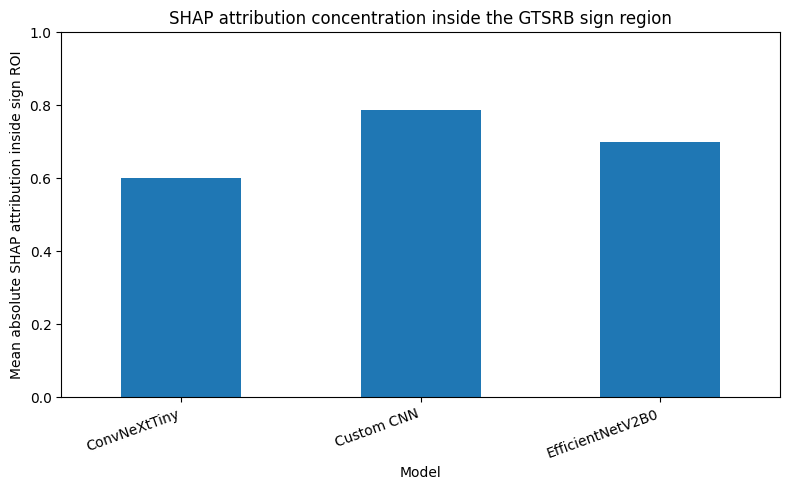

,model,sample_count,correct_count,mean_confidence,mean_shap_seconds,mean_absolute_attribution,mean_roi_absolute_attribution_ratio,median_roi_absolute_attribution_ratio
0,ConvNeXtTiny,6,4,0.888384,4.333420,0.639986,0.601282,0.675309
1,Custom CNN,6,4,0.868588,1.960916,0.645826,0.786889,0.790721
2,EfficientNetV2B0,6,4,0.755827,4.815723,0.796390,0.700020,0.696366


,model,selection_category,sample_count,correct_count,mean_confidence,mean_shap_seconds,mean_roi_absolute_attribution_ratio
0,ConvNeXtTiny,difficult_or_misclassified,2,0,0.999362,2.052694,0.843600
1,ConvNeXtTiny,high_confidence_correct,2,2,1.000000,8.892921,0.312185
2,ConvNeXtTiny,low_confidence_correct,2,2,0.665792,2.054645,0.648060
3,Custom CNN,difficult_or_misclassified,2,0,0.989007,1.528661,0.784835
4,Custom CNN,high_confidence_correct,2,2,1.000000,2.768457,0.828146
5,Custom CNN,low_confidence_correct,2,2,0.616757,1.585631,0.747684
6,EfficientNetV2B0,difficult_or_misclassified,2,0,0.982588,1.563907,0.696366
7,EfficientNetV2B0,high_confidence_correct,2,2,1.000000,11.177833,0.713017
8,EfficientNetV2B0,low_confidence_correct,2,2,0.284893,1.705428,0.690679


{
  "selected_samples": 6,
  "models": [
    "Custom CNN",
    "EfficientNetV2B0",
    "ConvNeXtTiny"
  ],
  "shap_records": 18,
  "explainer": "PartitionExplainer",
  "masker": "blur(32,32)",
  "max_evals": 300,
  "roi_available": true,
  "highest_mean_roi_attribution_model": "Custom CNN"
}


In [12]:

shap_frame = pd.DataFrame(
    shap_records
)

shap_frame.to_csv(
    REPORT_DIR / "shap_records.csv",
    index=False,
)

summary_aggregations = {
    "sample_count": (
        "sample_id",
        "count",
    ),
    "correct_count": (
        "correct",
        "sum",
    ),
    "mean_confidence": (
        "confidence",
        "mean",
    ),
    "mean_shap_seconds": (
        "shap_seconds",
        "mean",
    ),
    "mean_absolute_attribution": (
        "absolute_attribution_sum",
        "mean",
    ),
}

if ROI_AVAILABLE:
    summary_aggregations[
        "mean_roi_absolute_attribution_ratio"
    ] = (
        "roi_absolute_attribution_ratio",
        "mean",
    )

    summary_aggregations[
        "median_roi_absolute_attribution_ratio"
    ] = (
        "roi_absolute_attribution_ratio",
        "median",
    )

model_summary_frame = (
    shap_frame
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        **summary_aggregations
    )
)

model_summary_frame.to_csv(
    REPORT_DIR / "shap_model_summary.csv",
    index=False,
)

category_summary_frame = (
    shap_frame
    .groupby(
        [
            "model",
            "selection_category",
        ],
        as_index=False,
    )
    .agg(
        sample_count=(
            "sample_id",
            "count",
        ),
        correct_count=(
            "correct",
            "sum",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        mean_shap_seconds=(
            "shap_seconds",
            "mean",
        ),
        mean_roi_absolute_attribution_ratio=(
            "roi_absolute_attribution_ratio",
            "mean",
        ),
    )
)

category_summary_frame.to_csv(
    REPORT_DIR / "shap_category_summary.csv",
    index=False,
)

summary_json = {
    "selected_samples": int(
        len(selected_frame)
    ),
    "models": list(
        MODEL_PATHS.keys()
    ),
    "shap_records": int(
        len(shap_frame)
    ),
    "explainer": "PartitionExplainer",
    "masker": MASKER_SPECIFICATION,
    "max_evals": MAX_EVALS,
    "roi_available": bool(
        ROI_AVAILABLE
    ),
}

if ROI_AVAILABLE:
    valid_roi_summary = (
        model_summary_frame
        .dropna(
            subset=[
                "mean_roi_absolute_attribution_ratio"
            ]
        )
    )

    if not valid_roi_summary.empty:
        best_index = valid_roi_summary[
            "mean_roi_absolute_attribution_ratio"
        ].idxmax()

        summary_json[
            "highest_mean_roi_attribution_model"
        ] = str(
            valid_roi_summary.loc[
                best_index,
                "model",
            ]
        )

(
    REPORT_DIR / "shap_summary.json"
).write_text(
    json.dumps(
        summary_json,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

if ROI_AVAILABLE:
    plt.figure(
        figsize=(8, 5)
    )

    plot_values = (
        model_summary_frame
        .set_index("model")[
            "mean_roi_absolute_attribution_ratio"
        ]
    )

    plot_values.plot(
        kind="bar"
    )

    plt.xlabel("Model")
    plt.ylabel(
        "Mean absolute SHAP attribution inside sign ROI"
    )
    plt.title(
        "SHAP attribution concentration inside the GTSRB sign region"
    )
    plt.xticks(
        rotation=20,
        ha="right",
    )
    plt.ylim(
        0.0,
        1.0,
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / "shap_roi_attribution_comparison.pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        FIGURE_DIR
        / "shap_roi_attribution_comparison.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

display(model_summary_frame)
display(category_summary_frame)

print(
    json.dumps(
        summary_json,
        indent=2,
        ensure_ascii=False,
    )
)


## Cell 13 — Verify outputs

In [13]:

required_outputs = [
    REPORT_DIR / "model_information.csv",
    REPORT_DIR / "clean_test_predictions_all_models.csv",
    REPORT_DIR / "selected_shap_samples.csv",
    REPORT_DIR / "shap_records.csv",
    REPORT_DIR / "shap_model_summary.csv",
    REPORT_DIR / "shap_category_summary.csv",
    REPORT_DIR / "shap_summary.json",
    FIGURE_DIR / "selected_original_samples.pdf",
]

if ROI_AVAILABLE:
    required_outputs.append(
        FIGURE_DIR
        / "shap_roi_attribution_comparison.pdf"
    )

missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        f"Missing expected outputs: {missing_outputs}"
    )

expected_records = (
    len(selected_frame)
    * len(MODEL_PATHS)
)

if len(shap_frame) != expected_records:
    raise RuntimeError(
        f"Expected {expected_records} SHAP records, "
        f"found {len(shap_frame)}."
    )

comparison_png_files = list(
    COMPARISON_DIR.glob(
        "*_comparison.png"
    )
)
comparison_pdf_files = list(
    COMPARISON_DIR.glob(
        "*_comparison.pdf"
    )
)
individual_png_files = list(
    INDIVIDUAL_DIR.rglob(
        "*.png"
    )
)
individual_pdf_files = list(
    INDIVIDUAL_DIR.rglob(
        "*.pdf"
    )
)
attribution_array_files = list(
    ATTRIBUTION_ARRAY_DIR.rglob(
        "*.npz"
    )
)

print(
    "Comparison PNG files:",
    len(comparison_png_files),
)
print(
    "Comparison PDF files:",
    len(comparison_pdf_files),
)
print(
    "Individual PNG files:",
    len(individual_png_files),
)
print(
    "Individual PDF files:",
    len(individual_pdf_files),
)
print(
    "Attribution array files:",
    len(attribution_array_files),
)

if len(comparison_png_files) != len(selected_frame):
    raise RuntimeError(
        "The number of comparison PNG files is incorrect."
    )

if len(comparison_pdf_files) != len(selected_frame):
    raise RuntimeError(
        "The number of comparison PDF files is incorrect."
    )

if len(individual_png_files) != expected_records:
    raise RuntimeError(
        "The number of individual PNG files is incorrect."
    )

if len(individual_pdf_files) != expected_records:
    raise RuntimeError(
        "The number of individual PDF files is incorrect."
    )

if len(attribution_array_files) != expected_records:
    raise RuntimeError(
        "The number of attribution array files is incorrect."
    )

print(
    "SHAP ANALYSIS COMPLETED SUCCESSFULLY."
)


Comparison PNG files: 6
Comparison PDF files: 6
Individual PNG files: 18
Individual PDF files: 18
Attribution array files: 18
SHAP ANALYSIS COMPLETED SUCCESSFULLY.


## Cell 14 — Create the final ZIP archive

In [14]:

archive_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "shap_results"
    ),
    format="zip",
    root_dir=OUTPUT_ROOT,
)

archive_path = Path(
    archive_path
)

if not archive_path.exists():
    raise FileNotFoundError(
        "The SHAP ZIP archive was not created."
    )

archive_size_mb = (
    archive_path.stat().st_size
    / 1024
    / 1024
)

print(
    "Archive created:",
    archive_path,
)
print(
    "Archive size, MB:",
    round(
        archive_size_mb,
        2,
    ),
)

if REMOVE_UNPACKED_OUTPUT_AFTER_ZIP:
    # Remove unpacked outputs to reduce Kaggle version publishing time.
    shutil.rmtree(OUTPUT_ROOT)

    print(
        "Unpacked output directory removed:",
        not OUTPUT_ROOT.exists(),
    )

print(
    "Final Kaggle output file:",
    archive_path,
)


Archive created: /kaggle/working/shap_results.zip
Archive size, MB: 12.5
Unpacked output directory removed: True
Final Kaggle output file: /kaggle/working/shap_results.zip
